In [15]:
import pandas as pd

import os
from dotenv import load_dotenv
load_dotenv()

True

In [16]:
PATH_DATA = os.getenv("PATH_DATA")

df = pd.read_csv(f"{PATH_DATA}/earthquake_data.csv")
df

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,22-11-2022 02:03,8,7,green,1,768,us,117,0.509,17.0,mww,14.000,-9.7963,159.596,"Malango, Solomon Islands",Oceania,Solomon Islands
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,18-11-2022 13:37,4,4,green,0,735,us,99,2.229,34.0,mww,25.000,-4.9559,100.738,"Bengkulu, Indonesia",NaN,NaN
2,M 7.0 -,7.0,12-11-2022 07:09,3,3,green,1,755,us,147,3.125,18.0,mww,579.000,-20.0508,-178.346,NaN,Oceania,Fiji
3,"M 7.3 - 205 km ESE of Neiafu, Tonga",7.3,11-11-2022 10:48,5,5,green,1,833,us,149,1.865,21.0,mww,37.000,-19.2918,-172.129,"Neiafu, Tonga",NaN,NaN
4,M 6.6 -,6.6,09-11-2022 10:14,0,2,green,1,670,us,131,4.998,27.0,mww,624.464,-25.5948,178.278,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,"M 7.7 - 28 km SSW of Puerto El Triunfo, El Sal...",7.7,13-01-2001 17:33,0,8,NaN,0,912,us,427,0.000,0.0,mwc,60.000,13.0490,-88.660,"Puerto El Triunfo, El Salvador",NaN,NaN
778,"M 6.9 - 47 km S of Old Harbor, Alaska",6.9,10-01-2001 16:02,5,7,NaN,0,745,ak,0,0.000,0.0,mw,36.400,56.7744,-153.281,"Old Harbor, Alaska",North America,NaN
779,"M 7.1 - 16 km NE of Port-Olry, Vanuatu",7.1,09-01-2001 16:49,0,7,NaN,0,776,us,372,0.000,0.0,mwb,103.000,-14.9280,167.170,"Port-Olry, Vanuatu",NaN,Vanuatu
780,"M 6.8 - Mindanao, Philippines",6.8,01-01-2001 08:54,0,5,NaN,0,711,us,64,0.000,0.0,mwc,33.000,6.6310,126.899,"Mindanao, Philippines",NaN,NaN


In [17]:
# Liste des colonnes à supprimer (inutiles ou géographiques)
colonnes_a_supprimer = [
    'title', 'date_time', 'net', 'magType', 'latitude', 'longitude', 'location', 'continent', 'country',
    'cdi', 'mmi', 'tsunami' # colonnes catégorielles
]

# On retire les colonnes si elles existent
df_clean = df.drop(columns=[col for col in colonnes_a_supprimer if col in df.columns])
df_clean.head()

,magnitude,alert,sig,nst,dmin,gap,depth
0,7.0,green,768,117,0.509,17.0,14.000
1,6.9,green,735,99,2.229,34.0,25.000
2,7.0,green,755,147,3.125,18.0,579.000
3,7.3,green,833,149,1.865,21.0,37.000
4,6.6,green,670,131,4.998,27.0,624.464


In [18]:
# Jeu de données pour la prédiction de 'sig'
df_sig = df_clean.drop(columns=['alert']) if 'alert' in df_clean.columns else df_clean.copy()
df_sig.head()

,magnitude,sig,nst,dmin,gap,depth
0,7.0,768,117,0.509,17.0,14.000
1,6.9,735,99,2.229,34.0,25.000
2,7.0,755,147,3.125,18.0,579.000
3,7.3,833,149,1.865,21.0,37.000
4,6.6,670,131,4.998,27.0,624.464


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_sig = df_sig.drop(columns=['sig'])
colonnes_numeriques_sig = X_sig.select_dtypes(include=['float64', 'int64']).columns
scaler_sig = StandardScaler()
X_sig_scaled = X_sig.copy()
X_sig_scaled[colonnes_numeriques_sig] = scaler_sig.fit_transform(X_sig[colonnes_numeriques_sig])
y_sig = df_sig['sig']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sig_scaled, y_sig, test_size=0.2, random_state=42)

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

# Recherche simple d'hyperparamètres pour RandomForestRegressor
param_grid_rf = {'n_estimators': [50, 100], 'max_depth': [3, 5, None]}
rf = RandomForestRegressor(random_state=42)
gs_rf = GridSearchCV(rf, param_grid_rf, cv=3)
gs_rf.fit(X_train_s, y_train_s)
y_pred_s = gs_rf.predict(X_test_s)
print('MSE (sig):', mean_squared_error(y_test_s, y_pred_s))

MSE (sig): 94683.01342809791


In [ ]:
import numpy as np

y_pred_s = gs_rf.predict(X_test_s)
rmse_clean_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
print(rmse_clean_s)

307.70605035991395


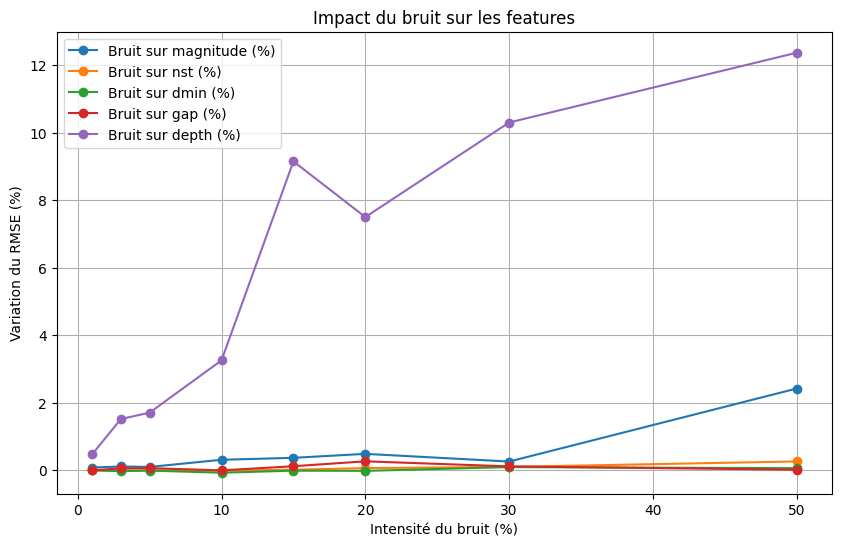

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings("ignore")

def evaluate_noise_impact(model, X_base, y_true, feature_idx, noise_level, scaler, rmse_clean):
    """
    Crée une copie de X, bruite une seule feature, et retourne la MSE.
    """
    X_noisy = X_base.copy()

    std_dev = X_base[:, feature_idx].std()

    noise = np.random.normal(loc=0, scale=std_dev * noise_level / 100, size=X_noisy.shape[0])
    X_noisy[:, feature_idx] += noise
    X_noisy = scaler.transform(X_noisy)

    preds_noisy = model.predict(X_noisy)
    rmse_noisy = np.sqrt(mean_squared_error(preds_noisy, y_true))
    variation = 100 * (rmse_noisy - rmse_clean) / rmse_clean

    diff_max = np.max(X_noisy[:, feature_idx]) - np.min(X_noisy[:, feature_idx])

    return variation


def plot_noise_impact(intensities, mse_values, feature_names):
    plt.figure(figsize=(10, 6))
    for idx, mse in enumerate(mse_values):
        plt.plot(intensities, mse, 'o-', label=f"Bruit sur {feature_names[idx]} (%)")
    plt.title("Impact du bruit sur les features")
    plt.xlabel("Intensité du bruit (%)")
    plt.ylabel("Variation du RMSE (%)")
    plt.legend()
    plt.grid()
    plt.show()

# Affichage de la courbe
intensities = np.array([1, 3, 5, 10, 15, 20, 30, 50])
n_repeats = 10

X_train_s_, X_test_s_, y_train_s_, y_test_s_ = train_test_split(X_sig, y_sig, test_size=0.2, random_state=42)

mse_values_s = []
for idx in range(X_sig.shape[1]):
    mse_values_s.append([
        np.mean([
            evaluate_noise_impact(gs_rf, X_test_s_.to_numpy(), y_test_s_, idx, n, scaler_sig, rmse_clean_s)
            for _ in range(n_repeats)
        ])
        for n in intensities
    ])

plot_noise_impact(intensities, mse_values_s, X_sig.columns)


---
---
### Interprétation
- Ce graphique montre que le modèle n’a pas la même sensibilité au bruit selon les variables. La feature depth est de loin la plus impactante : plus le bruit augmente, plus la dégradation du RMSE devient importante. À l’inverse, nst, dmin et gap ont un effet très faible, tandis que magnitude a un impact modéré, surtout pour les niveaux de bruit les plus élevés.
---
---